# OPD 在线蒸馏

不让小模型从零探索，而是让强模型在它自己生成的轨迹上逐 token 给指导。这条路线叫在线策略蒸馏（On-Policy Distillation, OPD）

## **OPD 的直观理解**

**OPD：**
- 学生自己开始写答案
- 即使学生前面写歪了，老师也继续看着学生当前的内容
- 老师在每一步告诉学生："你刚才选的这个词，我认为合理/不合理"
- 学生根据这些逐词反馈调整

**所以：**
- **SFT** 是"看老师怎么写"
- **OPD** 是"在自己写的过程中接受老师批改"

**数学上到底优化什么**

在生成第 $t$ 个 token 时，当前状态是：

$$s_t=(\text{题目}+\text{学生此前生成的内容})$$

学生模型给出下一个 token 的概率分布：

$$\pi_S(a\mid s_t)$$

教师模型也针对完全相同的上下文给出一个概率分布：

$$\pi_T(a\mid s_t)$$

OPD 想最小化：

$$D_{\mathrm{KL}}\left(\pi_S(\cdot\mid s_t)\,\|\,\pi_T(\cdot\mid s_t)\right)$$

**翻译成人话：** 在学生当前走到的这个位置，让学生对"下一步该写什么"的判断越来越像老师。

**整个训练目标**

$$\min_\theta \mathbb{E}_{s_t\sim \text{student rollout}} \left[ D_{\mathrm{KL}}(\pi_S\|\pi_T) \right]$$

**这里包含两个重点：**
- **外层**：训练位置来自学生自己生成的回答
- **内层**：在这些位置上缩小学生与老师的概率分布差异

**每个 token 的信号怎么来的**

学生实际采样出了一个 token $a_t$ 后，可以计算：

$$A_t = \log \pi_T(a_t\mid s_t) - \log \pi_S(a_t\mid s_t)$$

你可以暂时把 $A_t$ 理解成这个 token 的"相对奖励"：

- $A_t>0$：老师比学生自己更认可这个 token，应提高它的概率
- $A_t<0$：学生过度偏爱这个 token，但老师不认可，应降低它的概率
- $A_t\approx0$：师生对这个 token 的看法差不多

## 术语

![image.png](attachment:image.png)

白盒蒸馏看 teacher logits，黑盒蒸馏只看 teacher 输出

## 普通蒸馏 vs OPD

### 图一：普通蒸馏（SFT / SeqKD）

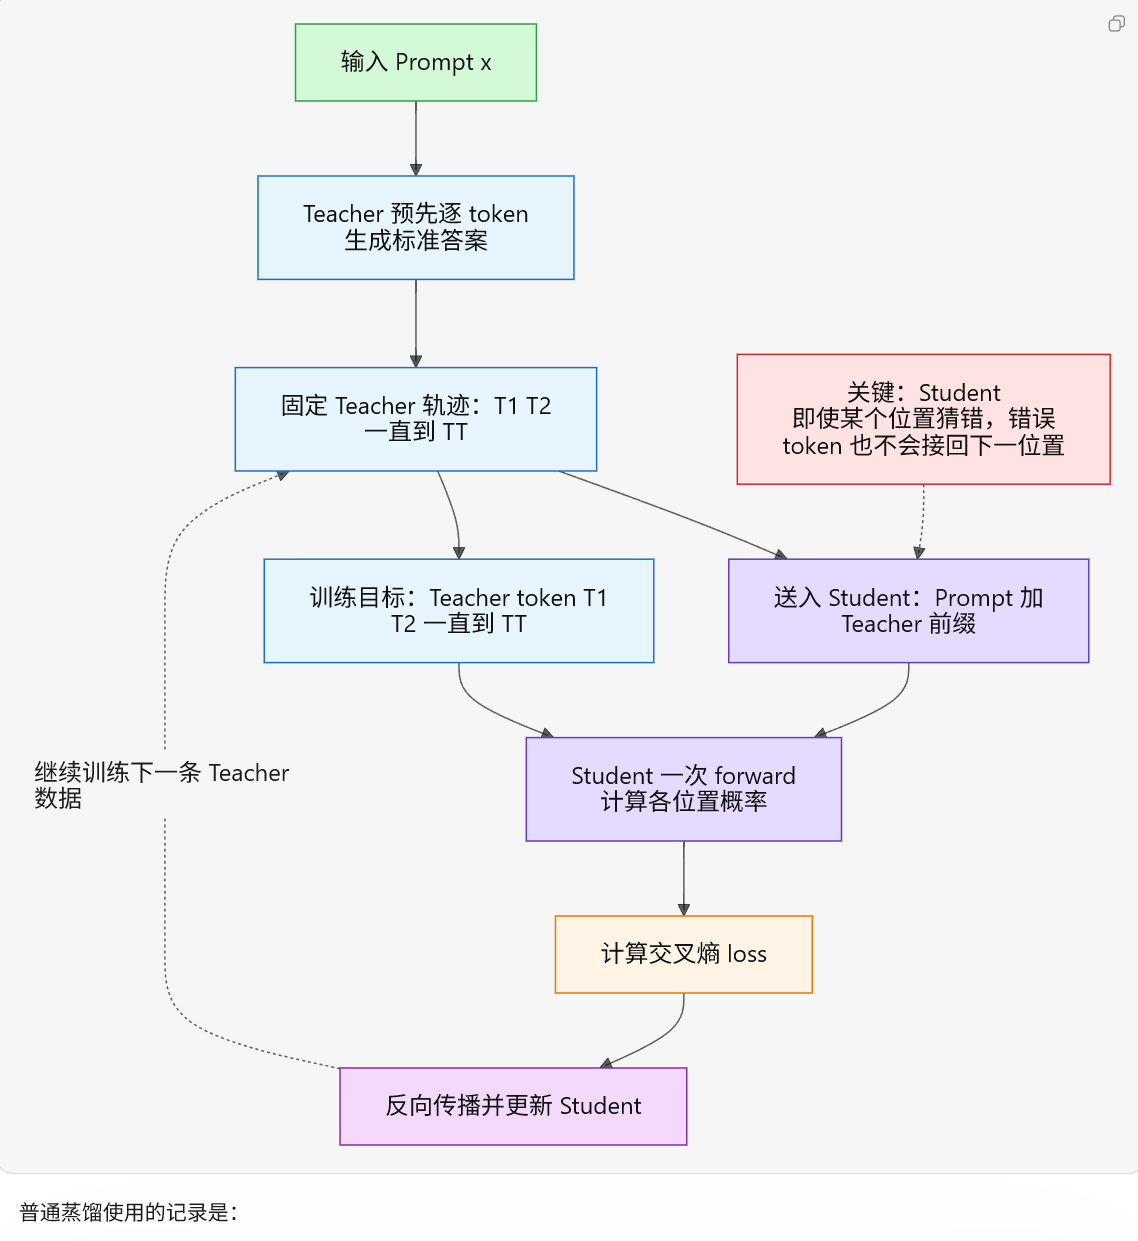

**关键标注：** 整条训练记录由 Teacher 生成；训练前缀来自 Teacher token。Student 即使在某个位置猜错，错误 token 也不会接回下一位置。

### 图二：OPD（On-Policy Distillation）
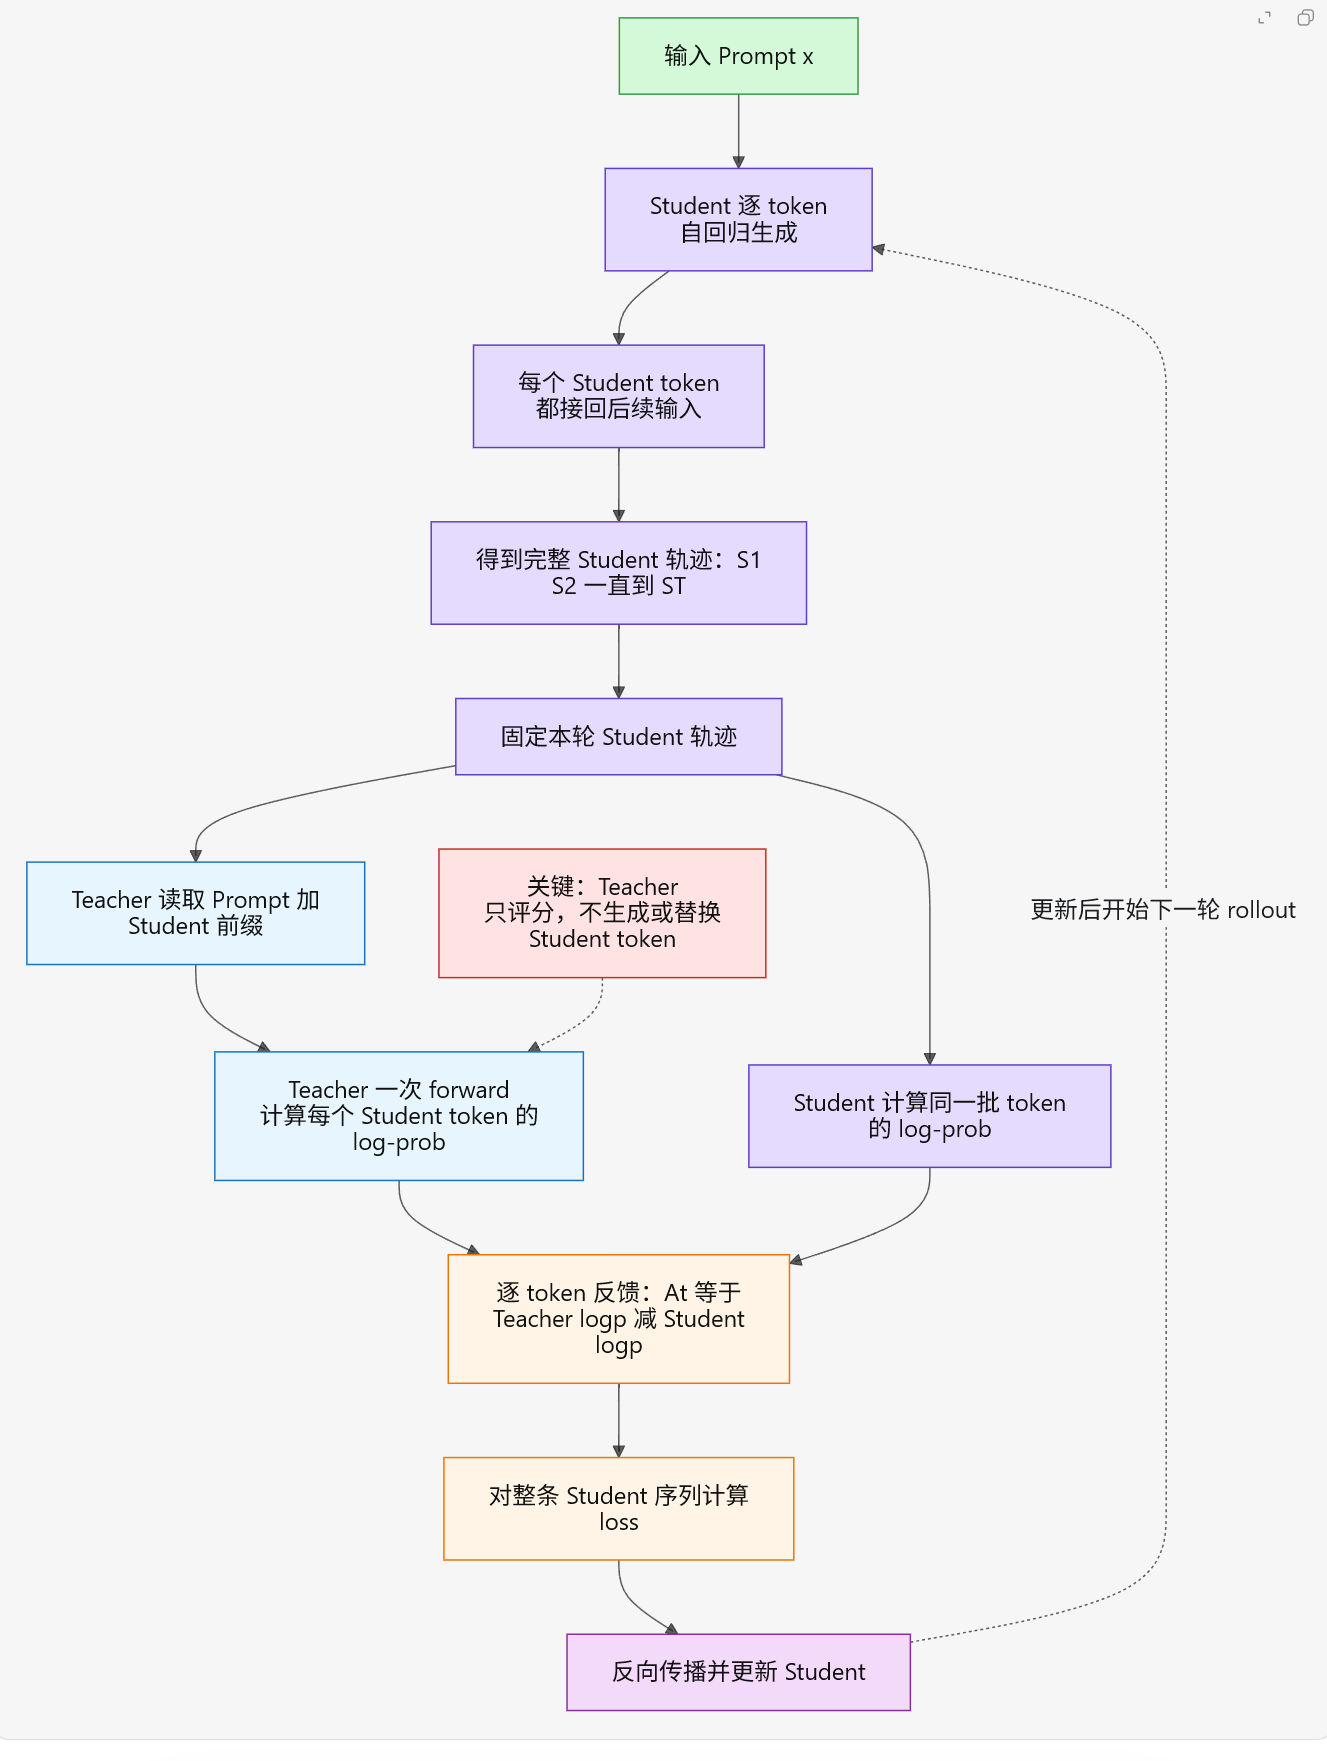

**关键标注：** 整条训练记录由 Student 生成；训练前缀来自 Student token。Teacher 只计算 Student token 的 log-prob 并评分，不生成或替换 Student token。

# AI笔记可忽略

## 为什么要使用 Reverse KL （防止平滑）

### 先说结论

在 OPD 中，Teacher 分布记为 $q$，Student 分布记为 $\pi_\theta$。之所以常用

$$D_{\mathrm{KL}}(\pi_\theta\|q)$$

而不是

$$D_{\mathrm{KL}}(q\|\pi_\theta)$$

核心原因不只是 Reverse KL 更容易产生“集中火力”的效果，更重要的是：

> **Reverse KL 的期望分布正好是 Student。OPD 已经由 Student 生成 on-policy rollout，因此可以直接在 Student 实际访问的状态和实际采样的 token 上估计它。**

---

### Forward KL 和 Reverse KL 的位置为什么不对称

#### Forward KL

$$
D_{\mathrm{KL}}(q\|\pi_\theta)
=
\sum_x q(x)\log\frac{q(x)}{\pi_\theta(x)}
=
\mathbb E_{x\sim q}
\left[
\log q(x)-\log\pi_\theta(x)
\right]
$$

外面的权重是 $q(x)$，所以它重点关注 **Teacher 有概率质量的区域**。

把各个 $\pi_\theta(x)$ 暂时当成独立变量，其局部导数为：

$$
\frac{\partial D_{\mathrm{KL}}(q\|\pi_\theta)}
{\partial \pi_\theta(x)}
=
-\frac{q(x)}{\pi_\theta(x)}
$$

如果 Teacher 认为某个 token 有明显概率，即 $q(x)>0$，但 Student 给它的概率非常小，那么

$$
\frac{q(x)}{\pi_\theta(x)}
$$

会很大，训练会强烈推动 Student 不要漏掉这个 token。

因此 Forward KL 常被称为：

- **Zero-avoiding**：不愿意让 Student 在 Teacher 支持的区域给出零概率；
- **Mode-covering**：倾向于覆盖 Teacher 的多个可能模式；
- 在生成任务中，如果 Student 容量有限，可能表现得更加平滑、分散。

#### Reverse KL

$$
D_{\mathrm{KL}}(\pi_\theta\|q)
=
\sum_x\pi_\theta(x)\log\frac{\pi_\theta(x)}{q(x)}
=
\mathbb E_{x\sim\pi_\theta}
\left[
\log\pi_\theta(x)-\log q(x)
\right]
$$

外面的权重变成了 $\pi_\theta(x)$，所以它重点关注 **Student 自己实际放置概率质量的区域**。

局部导数是：

$$
\frac{\partial}
{\partial\pi_\theta(x)}
\left[
\pi_\theta(x)\log\frac{\pi_\theta(x)}{q(x)}
\right]
=
\log\frac{\pi_\theta(x)}{q(x)}+1
$$

这里需要注意符号：

> 正确结果是 $\log\frac{\pi_\theta(x)}{q(x)}+1$，不是 $\log\frac{q(x)}{\pi_\theta(x)}+1$。如果优化的是负 KL，整体符号才会反过来。

当 Student 给某个 token 很高的概率，而 Teacher 给它的概率很低时，

$$
\log\frac{\pi_\theta(x)}{q(x)}
$$

会很大，Student 会受到强烈压力，把概率从这个 Teacher 不认可的 token 上移走。

反过来，如果 Student 几乎不给某个 token 概率，那么这一项

$$
\pi_\theta(x)\log\frac{\pi_\theta(x)}{q(x)}
$$

也会趋近于 $0$。在基于 Student 采样的训练中，这个 token 甚至可能根本不会被采到，因此缺少直接训练信号。

所以 Reverse KL 常表现为：

- **Zero-forcing**：Student 可以把部分模式的概率压得很低；
- **Mode-seeking**：倾向于集中在 Teacher 高概率、同时 Student 自己能够访问到的少数模式上；
- 不强求 Student 覆盖 Teacher 的所有可能表达。

> 严格来说，如果 Student 分布没有容量限制，并且能够精确优化到全局最优，那么两种 KL 的最优解都是 $\pi_\theta=q$。所谓 mode-covering 和 mode-seeking，主要描述的是模型容量受限、分布多峰、有限采样和实际优化条件下的不同倾向。

---

### 为什么 Reverse KL 特别适合 OPD

OPD 的轨迹来自 Student：

$$
a_t\sim\pi_\theta(\cdot\mid s_t)
$$

其中状态

$$
s_t=(x,a_{<t})
$$

也来自 Student 自己已经生成的前缀。

Reverse KL 正好可以写成：

$$
D_{\mathrm{KL}}(\pi_\theta\|q)
=
\mathbb E_{a_t\sim\pi_\theta(\cdot\mid s_t)}
\left[
\log\pi_\theta(a_t\mid s_t)
-
\log q(a_t\mid s_t)
\right]
$$

这意味着训练流程天然匹配：

1. Student 在自己的状态 $s_t$ 上采样 token $a_t$；
2. Student 记录 $\log\pi_\theta(a_t\mid s_t)$；
3. Teacher 对同一个 Student token 计算 $\log q(a_t\mid s_t)$；
4. 两者相减，就得到这个 Student token 对 Reverse KL 的贡献。

Teacher 不需要替换 Student token，也不需要重新生成一条答案。Teacher 只需要对 Student 已经生成的轨迹评分。

Forward KL 的期望则在 Teacher 分布 $q$ 下：

$$
\mathbb E_{a\sim q}[\cdots]
$$

它更自然地对应 Teacher 采样、Teacher 轨迹或者完整 Teacher logits，而不是 Student 的 on-policy rollout。这会削弱 OPD 最想保留的特性：**在 Student 自己真正会到达的状态上训练。**

---

### 最容易混淆的负号：KL、Reward 和 Loss

#### 目标一：从数学上最小化 Reverse KL

最原始的优化目标是：

$$
\min_\theta
D_{\mathrm{KL}}(\pi_\theta\|q)
$$

即最小化：

$$
\mathbb E_{a_t\sim\pi_\theta}
\left[
\log\pi_\theta(a_t\mid s_t)
-
\log q(a_t\mid s_t)
\right]
$$

如果直接把 Reverse KL 当作 loss，就不需要额外添加负号。

#### 目标二：RL 代码通常最大化 Reward

强化学习通常写成最大化目标：

$$
\max_\theta J(\theta)
$$

因此可以把 Reverse KL 的负数定义为 reward：

$$
r_t
=
-
\left[
\log\pi_\theta(a_t\mid s_t)
-
\log q(a_t\mid s_t)
\right]
$$

整理后：

$$
\boxed{
r_t
=
\log q(a_t\mid s_t)
-
\log\pi_\theta(a_t\mid s_t)
}
$$

这就是 OPD 中常见的 token 级反馈：

$$
A_t
=
\text{Teacher logp}
-
\text{Student logp}
$$

它被称为“负 Reverse KL 信号”，因为：

$$
\mathbb E_{\pi_\theta}[A_t]
=
-
D_{\mathrm{KL}}(\pi_\theta\|q)
$$

所以最大化 $A_t$ 的期望，就等价于最小化 Reverse KL。

#### 目标三：优化器最终还是最小化 Loss

深度学习优化器通常执行：

$$
\min_\theta\mathcal L_{\mathrm{train}}
$$

而 RL 目标是最大化 $J(\theta)$，因此代码里通常再写：

$$
\mathcal L_{\mathrm{train}}=-J(\theta)
$$

如果用最简化的 policy-gradient 形式表示：

$$
\mathcal L_{\mathrm{PG}}
=
-
\mathbb E
\left[
A_t\log\pi_\theta(a_t\mid s_t)
\right]
$$

于是完整的符号链是：

$$
\boxed{
\min D_{\mathrm{KL}}
\quad\Longleftrightarrow\quad
\max(-D_{\mathrm{KL}})
\quad\Longleftrightarrow\quad
\min[-(-D_{\mathrm{KL}})]
}
$$

可以这样记：

| 所在层次 | 写法 | 方向 |
|---|---|---|
| 数学距离 | $D_{\mathrm{KL}}(\pi_\theta\|q)$ | 最小化 |
| OPD reward / advantage | $A_t=\log q-\log\pi_\theta$ | 最大化 |
| 训练代码中的 loss | $\mathcal L=-J$ | 最小化 |

所以“最后带负号”并不是把 Reverse KL 变成另一种 KL，而是因为：

> **KL 是要最小化的距离；RL 把它取负后当成要最大化的奖励；优化器又把最大化目标取负，转换成要最小化的 loss。**

---

### 用两个 token 检查符号

假设 Student 实际采到了 token $a_t$。

#### Teacher 比 Student 更认可

$$
q(a_t\mid s_t)=0.8,\qquad
\pi_\theta(a_t\mid s_t)=0.2
$$

那么：

$$
A_t=\log0.8-\log0.2=\log4>0
$$

它是正 advantage，训练会提高这个 token 的概率。

#### Student 过度认可，但 Teacher 不认可

$$
q(a_t\mid s_t)=0.01,\qquad
\pi_\theta(a_t\mid s_t)=0.6
$$

那么：

$$
A_t=\log0.01-\log0.6<0
$$

它是负 advantage，训练会降低这个 token 的概率。

这正好符合 OPD 的直觉：

> Teacher 比 Student 更认可的 Student token 被强化；Student 过度偏爱但 Teacher 不认可的 token 被压低。

---

### 通俗类比

- **Forward KL**：Teacher 给出一张“值得尝试的完整菜单”。只要 Teacher 认为某道菜有价值，Student 就尽量不要漏掉，因此更像覆盖 Teacher 的广度。
- **Reverse KL**：Student 先自己点菜，Teacher 评价 Student 已经点出的菜。点了 Teacher 很讨厌的菜会被重罚；没有点到的菜通常得不到直接反馈，因此 Student 更容易集中在少数安全、受 Teacher 认可的招牌菜上。

OPD 正好属于第二种场景：**Student 先点菜，Teacher 再评分。**

### 一句话总结

> OPD 使用 Reverse KL，是因为它能直接利用 Student 的 on-policy 轨迹：重点惩罚 Student 自己高概率但 Teacher 不认可的 token。实现时通常把 Reverse KL 取负，得到 $A_t=\text{Teacher logp}-\text{Student logp}$ 作为要最大化的 token 级反馈，最后再取负写成优化器要最小化的训练 loss。


## 蒸馏训练配方：SFT + Reverse KL OPD

### 为什么不建议从弱初始化直接做 OPD

Reverse KL 在 OPD 中写成：

$$
D_{\mathrm{KL}}(\pi_\theta\|q)
=
\mathbb E_{a_t\sim\pi_\theta(\cdot\mid s_t)}
\left[
\log\pi_\theta(a_t\mid s_t)
-
\log q(a_t\mid s_t)
\right]
$$

它的期望分布是 Student，因此训练信号主要来自 Student 自己实际采样到的 token。

如果某个关键 token 在 Student 初始化中的概率极低，那么实际 rollout 中几乎采不到它。Teacher 即使非常认可这个 token，也没有机会在采样数据上给它正反馈。

> Softmax 通常不会让 token 的理论概率严格等于 $0$，但概率可以小到在有限次 rollout 中一次都采不到。此时从训练效果上看，就等同于没有这个 token。

因此 Reverse KL OPD 存在一个现实限制：

> **它擅长重新排列 Student 已经能够想到的候选，但不擅长凭空教会 Student 一个从未采到的新模式。**

这也是为什么实用训练流程通常分成两个阶段：

```text
Teacher 生成高质量轨迹
        ↓
阶段一：SFT / SeqKD 冷启动
        ↓
Student 进入 Teacher 支持集附近
        ↓
阶段二：Reverse KL OPD
        ↓
在 Student 自己的状态上逐 token 精修
```

---

### 阶段一：使用 SFT / SeqKD 做离策略蒸馏

首先让 Teacher 针对训练 prompt 生成高质量回答：

$$
y^T=(y_1^T,\ldots,y_T^T)\sim q(\cdot\mid x)
$$

然后使用标准自回归交叉熵训练 Student：

$$
\boxed{
\mathcal L_{\mathrm{SFT}}
=
-
\sum_{t=1}^{T}
\log\pi_\theta
\left(
y_t^T
\mid
x,y_{<t}^T
\right)
}
$$

这里：

- 训练轨迹来自 Teacher；
- 输入前缀是 Teacher token；
- 目标 token 也是 Teacher token；
- Student 自己在训练时更想预测什么，不会被接回下一位置。

这一阶段属于 off-policy distillation，因为数据分布来自 Teacher，而不是当前 Student。

#### SFT 冷启动解决什么

SFT 的主要作用不是解决 Student 自身状态上的错误，而是：

1. 让 Student 学会基本任务格式和推理结构；
2. 把关键 token、关键步骤和 Teacher 的思维模式放进 Student 的可采样区域；
3. 增加 Teacher 与 Student 的 token 支持集重叠；
4. 避免 OPD 初期只看到大量低质量、Teacher 全部不认可的 rollout；
5. 给后续 on-policy 优化一个稳定起点。

可以把它理解为：

> **SFT 先把 Student 带到正确道路附近，让 Student 至少看得见正确出口。**

---

### 阶段二：使用 Reverse KL OPD 精修

完成 SFT 后，让当前 Student 自己生成新轨迹：

$$
y^S=(y_1^S,\ldots,y_T^S)
\sim
\pi_\theta(\cdot\mid x)
$$

状态来自 Student 自己的前缀：

$$
s_t=(x,y_{<t}^S)
$$

对于 Student 实际生成的 token $y_t^S$，分别计算：

$$
\log\pi_\theta(y_t^S\mid s_t)
$$

和：

$$
\log q(y_t^S\mid s_t)
$$

得到负 Reverse KL 形式的 token 级反馈：

$$
\boxed{
A_t
=
\log q(y_t^S\mid s_t)
-
\log\pi_\theta(y_t^S\mid s_t)
}
$$

其中：

- $A_t>0$：Teacher 比 Student 更认可这个 token，提高它的概率；
- $A_t<0$：Student 过度偏爱但 Teacher 不认可，降低它的概率；
- $A_t\approx0$：Teacher 与 Student 对这个 token 的判断接近。

再用 policy-gradient、PPO-style 或其他 importance-sampling loss 更新 Student。例如最简化形式：

$$
\mathcal L_{\mathrm{OPD}}
=
-
\mathbb E
\left[
A_t
\log\pi_\theta(y_t^S\mid s_t)
\right]
$$

实际实现中，$A_t$ 通常由 rollout 时的 Student log-prob 和 Teacher log-prob 计算，并在策略更新时停止梯度或按具体算法处理。

#### OPD 精修解决什么

OPD 的主要作用是：

1. 在 Student 推理时真正会到达的前缀上训练；
2. 修正 Student 自己容易选择的错误 token；
3. 缓解 SFT 中 Teacher 前缀与 Student 推理前缀之间的 exposure bias；
4. 使用密集的 token 级 Teacher 信号，而不是只有最终答案奖励；
5. 让 Student 在已有能力附近学习 Teacher 更细粒度的局部取舍。

可以把它理解为：

> **OPD 让 Student 自己开车，再让 Teacher 在 Student 实际经过的路口逐步纠偏。**

---

### 两个阶段分别解决不同问题

| 阶段 | 轨迹来源 | 前缀来源 | 训练信号 | 主要解决的问题 |
|---|---|---|---|---|
| SFT / SeqKD | Teacher | Teacher token | 标准答案交叉熵 | Student 不会正确模式、关键 token 采不到 |
| Reverse KL OPD | Student | Student token | Teacher logp − Student logp | Student 在自己的状态上容易走错、SFT 有分布偏移 |

两者是互补关系：

$$
\boxed{
\text{SFT 负责能力和支持集冷启动}
\quad+\quad
\text{OPD 负责 on-policy 局部精修}
}
$$

只做 SFT 的问题：

- Student 只在 Teacher 的正确前缀上训练；
- 推理时一旦进入自己的错误前缀，可能不知道如何继续；
- 存在 exposure bias。

直接做 OPD 的问题：

- 弱 Student 生成的轨迹可能质量很差；
- 关键 token 概率太低，有限 rollout 中根本采不到；
- Teacher 只能持续否定 Student 已有选择，却难以提供可吸收的新方向；
- 师生支持集重叠不足时，Reverse KL 很容易学不动。

---

### 推荐的完整训练循环

#### 准备阶段

1. 收集训练 prompts；
2. 使用 Teacher 生成高质量答案或推理轨迹；
3. 过滤明显错误、格式异常和重复样本；
4. 得到 Teacher 蒸馏数据集。

#### SFT 冷启动阶段

1. 使用 Teacher 轨迹训练 Student；
2. 在独立验证集上检查任务正确率；
3. 检查 Student 是否已经能够生成基本正确的格式和推理结构；
4. 检查关键 token 是否已经有合理的采样概率。

#### Reverse KL OPD 阶段

1. 当前 Student 针对 prompts 生成 on-policy rollout；
2. 固定 Student 轨迹，不替换其中的 token；
3. Teacher 对同一条 Student 轨迹逐 token 计算 log-prob；
4. Student 计算对应 token 的旧策略 log-prob；
5. 计算 $A_t=\text{Teacher logp}-\text{Student logp}$；
6. 使用 OPD loss 更新 Student；
7. 更新后的 Student 重新生成 rollout；
8. 重复评分和更新。

```text
Teacher rollout 数据
        ↓
SFT / SeqKD
        ↓
SFT Student
        ↓
Student on-policy rollout
        ↓
Teacher 对 Student token 逐个评分
        ↓
Reverse KL OPD 更新
        ↓
新 Student 重新 rollout
        ↺
```

---

### 是否要在 OPD 阶段继续混合 SFT loss

实践中可以采用两种方式。

#### 方案一：严格分阶段

先只优化：

$$
\mathcal L_{\mathrm{SFT}}
$$

然后切换为：

$$
\mathcal L_{\mathrm{OPD}}
$$

优点是结构清晰，方便判断每个阶段的收益。

#### 方案二：OPD 阶段保留少量 SFT 正则

可以写成：

$$
\boxed{
\mathcal L_{\mathrm{total}}
=
\mathcal L_{\mathrm{OPD}}
+
\lambda_{\mathrm{SFT}}\mathcal L_{\mathrm{SFT}}
}
$$

如果任务还有最终答案验证器，也可以加入任务损失或序列级奖励：

$$
\mathcal L_{\mathrm{total}}
=
\mathcal L_{\mathrm{OPD}}
+
\lambda_{\mathrm{SFT}}\mathcal L_{\mathrm{SFT}}
+
\lambda_{\mathrm{task}}\mathcal L_{\mathrm{task}}
$$

保留少量 SFT 信号可能有助于：

- 防止 Student 在 OPD 中忘记基础格式；
- 降低训练初期的不稳定；
- 保持 Teacher 的关键推理模式；
- 避免只追逐局部 token 偏好而损害最终任务正确性。

但 $\lambda_{\mathrm{SFT}}$ 过大时，训练又会重新被 Teacher 轨迹主导，削弱 on-policy 精修的作用。

---

### 训练时重点监控

| 指标 | 需要关注的问题 |
|---|---|
| 任务正确率 | Teacher score 上升是否真的带来能力提升 |
| Teacher log-prob | Student token 是否逐渐更受 Teacher 认可 |
| Reverse KL | 师生分布是否靠近，以及是否突然爆炸 |
| Entropy | Student 是否过早坍缩到少数 token |
| 回答长度 | 是否通过极端变短或变长刷 Teacher score |
| 重复率 | 是否出现循环、模板化或重复输出 |
| Teacher / Student overlap | Teacher 的高概率 token 是否处于 Student 可采样区域 |

不能只看 OPD loss 是否下降，因为：

> **Loss 下降只说明 Student 在局部 token 分布上更像 Teacher，不自动保证最终答案更正确。**

---

### 最终总结

> **SFT / SeqKD 先解决“Student 根本不会、关键 token 采不到”的问题；Reverse KL OPD 再解决“Student 在自己真实生成的前缀上容易走错”的问题。**

推荐配方是：

$$
\boxed{
\text{Teacher 轨迹}
\rightarrow
\text{SFT 冷启动}
\rightarrow
\text{Student on-policy rollout}
\rightarrow
\text{Reverse KL OPD 精修}
}
$$

两阶段缺一不可：

- 没有 SFT，Student 与 Teacher 的支持集可能没有足够重叠，OPD 很难提供可吸收的方向；
- 没有 OPD，Student 只在 Teacher 的正确前缀上学习，无法充分处理自己推理时真正会遇到的状态。


## OPD 的缺点二：长思维链后段的 token reward 可能变成噪声

### 先说结论

> **OPD 虽然能给每个 token 一个 reward，但"每个位置都有数字"不等于"每个位置的指导都可靠"。**

在长思维链中，越往后生成，Student 前面犯错并累积偏移的机会越多。于是后面的 Student 前缀可能逐渐离开 Teacher 训练时熟悉的正常推理分布。Teacher 仍然可以输出 log-prob，但这些分数可能不再代表稳定、可信的教学意见。

---

### 前缀是怎样一步步偏离的

设第 $t$ 步的状态为：

$$
s_t=(x,y_{<t}^{S})
$$

其中 $x$ 是题目，$y_{<t}^{S}$ 是 Student 自己已经生成的前缀。

生成前段时，Student 的推理可能还比较正常：

$$
x \rightarrow \text{正确分析} \rightarrow \text{合理中间结论}
$$

这类状态通常也接近 Teacher 熟悉的分布，因此 Teacher 给出的

$$
\log q(y_t^S\mid s_t)
$$

比较有解释力。

但如果 Student 中途写错：

$$
x \rightarrow \text{错误假设} \rightarrow \text{继续沿错误假设推导}
\rightarrow \text{越来越奇怪的前缀}
$$

那么越到后面，状态 $s_t$ 越可能是 Teacher 很少见过的组合。此时 Teacher 虽然还会对每个候选 token 输出概率，但这个概率可能不稳定，对微小措辞很敏感，也不一定能指出怎样回到正确推理路线。

---

### 一个具体例子

题目要求计算：

$$
12\times 15
$$

Student 前面误写成：

> $12\times 15 = 12\times(10+4)$

从这里开始，后面的前缀已经建立在"$15=10+4$"这个错误事实上。Student 接着可能写：

> $=120+48=168$

Teacher 可以分别给"$120$""$+$""$48$""$168$"计算 log-prob，但问题在于：

- 这些 token 都处在一个错误前提之下；
- 只评价当前 token，未必能告诉 Student 应该回到前面把 $10+4$ 改成 $10+5$；
- 后面的 token 即使在错误前提内部逻辑连贯，也不代表整条推理正确；
- Teacher 如果很少在训练中见到这种异常前缀，它的概率判断本身也可能不稳定。

所以后段得到的密集反馈，可能只是"在错误道路上怎样继续写得更像话"，而不是"怎样返回正确道路"。

---

### 它与"只能在 Student 采样区域内修正"有什么区别

两者有关，但强调的弱点不同：

| 弱点 | 核心问题 |
|---|---|
| 缺点一：Student 与 Teacher 的候选 token 缺少重叠 | Student 根本采不到 Teacher 真正想教的关键 token，Teacher 只能批评已采到的 token |
| 缺点二：长链后段的前缀分布偏移 | Student 虽然持续产生 token，Teacher 也持续打分，但 Teacher 面对的是越来越陌生、越来越偏的上下文，评分质量可能下降 |

可以把它们分别记成：

- **缺点一：好答案进不来。**
- **缺点二：走得太偏以后，老师的评分也未必可信。**

---

### 为什么长思维链尤其严重

如果每一步都有一点偏离概率，那么序列越长，至少发生一次偏离的机会就越大。并且自回归生成会把前面的输出继续放进后面的输入：

$$
y_t^S\sim\pi_\theta(\cdot\mid x,y_{<t}^S)
$$

因此一次早期错误不仅影响当前 token，还会改变此后所有状态。长思维链会同时放大：

1. **Student 的状态偏移**：后续生成建立在自己的错误历史上；
2. **Teacher 的评分不确定性**：Teacher 被要求评价训练分布之外的异常前缀；
3. **信用分配困难**：最终失败可能源于很早的错误，但后面每个 token 都会收到局部反馈，很难判断真正应该修正哪一步。

---

### 常见缓解方法

- **先做 SFT 冷启动**：降低 Student 在推理前段就严重跑偏的概率；
- **限制或分段 rollout 长度**：不要让一次严重偏移污染过长的后续 token；
- **只使用 Teacher 较有把握的 token 反馈**：按 Teacher 置信度、熵或 Student–Teacher 分歧过滤、降权；
- **保留 SFT / KL 锚点**：在 OPD 精修时继续约束模型不要漂离高质量示范；
- **加入序列级或结果级 reward**：用答案正确性补充局部 token reward，避免"每个局部看似合理，但整条推理错误"；
- **在明显错误处截断或重新生成**：减少对异常后缀的学习。

### 一句话总结

> OPD 的 token reward 很密集，但长思维链越往后，Student 前缀越可能偏离正常分布；Teacher 在陌生前缀上的 log-prob 仍然是一个数，却可能逐渐从"可靠指导"退化成"带噪声的局部评价"。

---

### 附：SFT Loss vs OPD Loss 对比

**SFT Loss:** 
$$-\log P_{\text{student}}(\text{Target})$$

**OPD Loss:** 
$$-\log P_{\text{teacher}}(\text{Student\_Sample})$$

用公式表达区别，这里真的区别不在于 KL 公式如何表示，而在于生成的数据的链路：一个是学生模型生成的概率，另外一个是 teacher 模型生成的概率。

# OPD 的最小实现

主要的一个流程是先让 student 模型直接预测，然后拿他预测的 token 分别去取 student 和 teacher 在上面的 log prob，然后 `advantages = logP(teacher) - logP(Student)`，这个是 KL 散度，这里训练的目的是让他们两个的差距变小，这样 student 就从 teacher 里面拿到了老师的生成的各种策略，这个就是 OPD。

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

####################################创建模型#####################################################
student_name = "Qwen/Qwen2.5-0.5B-Instruct"
teacher_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(student_name)
student = AutoModelForCausalLM.from_pretrained(
    student_name, torch_dtype=torch.bfloat16, device_map="auto"
)
teacher = AutoModelForCausalLM.from_pretrained(
    teacher_name, torch_dtype=torch.bfloat16, device_map="auto"
)
student.eval()
teacher.eval()

prompt = "Solve: if x + 3 = 7, what is x? Show your work."
inputs = tokenizer(prompt, return_tensors="pt").to(student.device)
prompt_len = inputs["input_ids"].shape[1]

# Step 1: student 生成回答
with torch.no_grad():
    output_ids = student.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=True,
        temperature=0.7,
    )

full_ids = output_ids

# Step 2: 计算 student 和 teacher 的逐 token log-prob
def next_token_logps(model, input_ids):
    """计算模型对给定序列中每个 token 的 log probability。

    logps[:, i] 是位置 i 的 logits 预测的 token i+1 的 log-prob。
    """
    logits = model(input_ids).logits
    logps = torch.log_softmax(logits[:, :-1], dim=-1) # logots 是保留前n-1位
    next_ids = input_ids[:, 1:] # 正确答案是保留后n-1位
    return logps.gather(-1, next_ids.unsqueeze(-1)).squeeze(-1)

with torch.no_grad():
    student_logps = next_token_logps(student, full_ids)
    teacher_logps = next_token_logps(teacher, full_ids.to(teacher.device)).to(student_logps.device)

# Step 3: 计算逐 token reward（teacher 认可度 - student 自信度）
gen_mask = torch.zeros_like(student_logps, dtype=torch.bool)
gen_mask[:, prompt_len - 1 :] = True  # 只看生成部分


token_rewards = teacher_logps - student_logps
generated_ids = full_ids[:, 1:][gen_mask] # full_dis 是预测结果 [无用， B, C, D] 而他们是由logits的上一位推到出来的， logits：[要预测B， 要预测C， 要预测D， 要预测E]
generated_rewards = token_rewards[gen_mask]

for tok_id, reward in zip(generated_ids[:32], generated_rewards[:32]):
    token = tokenizer.decode([tok_id.item()])
    print(f"{token!r:12s} reward={reward.item():+.3f}")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

e:\anaconda3\envs\verl\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\bbfss\.cache\huggingface\hub\models--Qwen--Qwen2.5-1.5B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

KeyboardInterrupt: 

DPO、GRPO、RLVR 和 OPD 都在回答同一个问题：当我们不想完整跑传统 RLHF 时，训练信号还能从哪里来？ DPO 用偏好对，RLVR 用验证器，OPD 用 teacher。